In [5]:
import json
import sqlite3
from collections import Counter

import matplotlib.pyplot as plt


In [6]:
conn = sqlite3.connect('to_db/epstein.db')
cursor = conn.cursor()

flights_rows = cursor.execute(
    '''
    SELECT id, destination, passenger_names_json
    FROM flights
    WHERE passenger_names_json IS NOT NULL
      AND TRIM(passenger_names_json) != ''
    '''
).fetchall()

conn.close()
print(f'Total flights with passenger data: {len(flights_rows)}')


Total flights with passenger data: 3652


In [7]:
TARGET_DESTINATIONS = {
    'little st. james island, usvi',
    'little saint james',
    'cyril e king airport',
    'cyril e. king airport',
    'cyril e. king airport, usvi',
    'palm beach international, fl',
    'palm beach international airport',
    'miami international, fl',
    'miami international airport',
}

total_mentions = Counter()
target_destination_mentions = Counter()

for _flight_id, destination, passenger_names_json in flights_rows:
    destination_key = (destination or '').strip().lower()

    try:
        names = json.loads(passenger_names_json)
    except (TypeError, json.JSONDecodeError):
        continue

    if not isinstance(names, list):
        continue

    for name in names:
        if not isinstance(name, str):
            continue

        clean_name = name.strip()
        if not clean_name:
            continue

        total_mentions[clean_name] += 1
        if destination_key in TARGET_DESTINATIONS:
            target_destination_mentions[clean_name] += 1

ratio_rows = []
for name, total_count in total_mentions.items():
    target_count = target_destination_mentions.get(name, 0)
    ratio_pct = (target_count / total_count) * 100 if total_count else 0
    ratio_rows.append(
        {
            'name': name,
            'total_mentions': total_count,
            'target_destination_mentions': target_count,
            'ratio_pct': ratio_pct,
        }
    )

ratio_rows.sort(key=lambda row: (row['total_mentions'], row['ratio_pct']), reverse=True)

for row in ratio_rows[:15]:
    print(
        f"{row['name']}: total={row['total_mentions']}, "
        f"target={row['target_destination_mentions']}, "
        f"ratio={row['ratio_pct']:.2f}%"
    )


Ghislaine Maxwell: total=1152, target=401, ratio=34.81%
Jeff Epstein: total=1041, target=269, ratio=25.84%
Jeffrey Epstein: total=1007, target=352, ratio=34.96%
Sarah Kellen: total=672, target=271, ratio=40.33%
Larry Visoski: total=438, target=92, ratio=21.00%
Nadia Marcinkova: total=264, target=114, ratio=43.18%
Emmy Tayler: total=200, target=58, ratio=29.00%
Larry Morrison: total=98, target=30, ratio=30.61%
Lesley Groff: total=92, target=53, ratio=57.61%
A P: total=90, target=24, ratio=26.67%
Virginia Roberts: total=76, target=37, ratio=48.68%
Andrea Mitrovich: total=73, target=12, ratio=16.44%
Bill Hammond: total=66, target=8, ratio=12.12%
Bill Clinton: total=63, target=17, ratio=26.98%
Sophie Biddle: total=61, target=16, ratio=26.23%


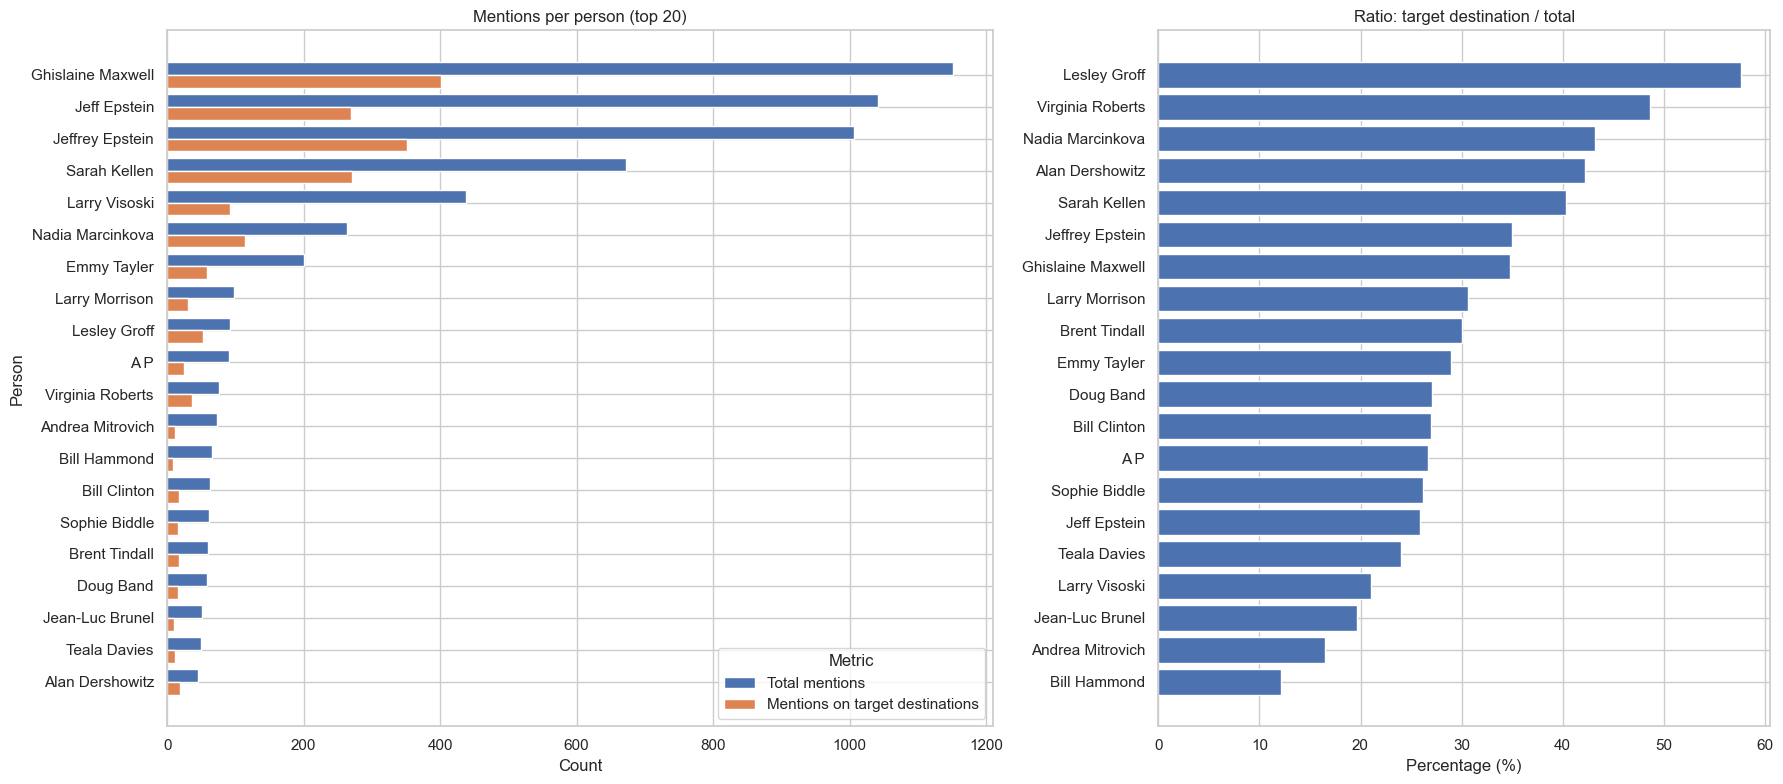

Ghislaine Maxwell: total=1152, target=401, ratio=34.81%
Jeff Epstein: total=1041, target=269, ratio=25.84%
Jeffrey Epstein: total=1007, target=352, ratio=34.96%
Sarah Kellen: total=672, target=271, ratio=40.33%
Larry Visoski: total=438, target=92, ratio=21.00%
Nadia Marcinkova: total=264, target=114, ratio=43.18%
Emmy Tayler: total=200, target=58, ratio=29.00%
Larry Morrison: total=98, target=30, ratio=30.61%
Lesley Groff: total=92, target=53, ratio=57.61%
A P: total=90, target=24, ratio=26.67%
Virginia Roberts: total=76, target=37, ratio=48.68%
Andrea Mitrovich: total=73, target=12, ratio=16.44%
Bill Hammond: total=66, target=8, ratio=12.12%
Bill Clinton: total=63, target=17, ratio=26.98%
Sophie Biddle: total=61, target=16, ratio=26.23%
Brent Tindall: total=60, target=18, ratio=30.00%
Doug Band: total=59, target=16, ratio=27.12%
Jean-Luc Brunel: total=51, target=10, ratio=19.61%
Teala Davies: total=50, target=12, ratio=24.00%
Alan Dershowitz: total=45, target=19, ratio=42.22%
Clare Ha

In [8]:
top_n = 20
plot_rows = ratio_rows[:top_n]

names = [row['name'] for row in plot_rows]
total_counts = [row['total_mentions'] for row in plot_rows]
target_counts = [row['target_destination_mentions'] for row in plot_rows]
ratio_values = [row['ratio_pct'] for row in plot_rows]

y_positions = list(range(len(plot_rows)))
bar_h = 0.4

fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1.35, 1]})

y_total = [y - bar_h / 2 for y in y_positions]
y_target = [y + bar_h / 2 for y in y_positions]

axes[0].barh(y_total, total_counts, height=bar_h, label='Total mentions')
axes[0].barh(y_target, target_counts, height=bar_h, label='Mentions on target destinations')
axes[0].set_title(f'Mentions per person (top {top_n})')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Person')
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(names)
axes[0].invert_yaxis()
axes[0].legend(title='Metric')

ratio_sorted_rows = sorted(plot_rows, key=lambda row: row['ratio_pct'], reverse=True)
ratio_names = [row['name'] for row in ratio_sorted_rows]
ratio_sorted_values = [row['ratio_pct'] for row in ratio_sorted_rows]
ratio_y = list(range(len(ratio_sorted_rows)))

axes[1].barh(ratio_y, ratio_sorted_values, color='#4C72B0')
axes[1].set_title('Ratio: target destination / total')
axes[1].set_xlabel('Percentage (%)')
axes[1].set_ylabel('')
axes[1].set_yticks(ratio_y)
axes[1].set_yticklabels(ratio_names)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

for row in ratio_rows[:30]:
    print(
        f"{row['name']}: total={row['total_mentions']}, "
        f"target={row['target_destination_mentions']}, "
        f"ratio={row['ratio_pct']:.2f}%"
    )
